# Data Overview and Cleaning

**Objective**: Load and clean raw data

**Steps**:
1. Import libraries
2. Explore first dataset (ECB rate)
3. Clean all datasets
4. Merge into final dataset

## 1. Setup

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

data_raw = '../01_data_raw/'
data_processed = '../02_data_processed/'
sys.path.append('../03_src')

print("Setup complete")

Setup complete


## 2. Explore ECB Data

In [53]:
df_ecb_raw = pd.read_csv(data_raw + 'ecb_rate.csv', sep=';')

print(f"Shape: {df_ecb_raw.shape}")
print(f"Columns: {df_ecb_raw.columns.tolist()}")
print("\nFirst rows:")
print(df_ecb_raw.head())
print("\nLast rows:")
print(df_ecb_raw.tail(10))
print("\nData types:")
print(df_ecb_raw.dtypes)
print("\nMissing values:")
print(df_ecb_raw.isnull().sum())

Shape: (295, 4)
Columns: ['date', 'ecb_rate', 'Unnamed: 2', 'Unnamed: 3']

First rows:
         date  ecb_rate  Unnamed: 2  Unnamed: 3
0  2005-01-31       2.0         NaN         NaN
1  2005-02-28       2.0         NaN         NaN
2  2005-03-31       2.0         NaN         NaN
3  2005-04-30       2.0         NaN         NaN
4  2005-05-31       2.0         NaN         NaN

Last rows:
    date  ecb_rate  Unnamed: 2  Unnamed: 3
285  NaN       NaN         NaN         NaN
286  NaN       NaN         NaN         NaN
287  NaN       NaN         NaN         NaN
288  NaN       NaN         NaN         NaN
289  NaN       NaN         NaN         NaN
290  NaN       NaN         NaN         NaN
291  NaN       NaN         NaN         NaN
292  NaN       NaN         NaN         NaN
293  NaN       NaN         NaN         NaN
294  NaN       NaN         NaN         NaN

Data types:
date           object
ecb_rate      float64
Unnamed: 2    float64
Unnamed: 3    float64
dtype: object

Missing values:
date    

### Issues found

- Empty columns (Unnamed: 2, Unnamed: 3)
- Empty rows at the end
- Date is text, need to convert to datetime
- ECB rate is already numeric

### Clean ECB data

In [54]:
df_ecb = df_ecb_raw.copy()

# Drop empty columns
df_ecb = df_ecb.drop(columns=['Unnamed: 2', 'Unnamed: 3'])

# Remove empty rows
df_ecb = df_ecb.dropna(subset=['ecb_rate'])

# Convert date to datetime
df_ecb['date'] = pd.to_datetime(df_ecb['date'])
df_ecb = df_ecb.set_index('date')

print(f"Cleaned: {df_ecb.shape}")
print(f"Date range: {df_ecb.index.min()} to {df_ecb.index.max()}")
print(df_ecb.head())

Cleaned: (241, 1)
Date range: 2005-01-31 00:00:00 to 2025-01-31 00:00:00
            ecb_rate
date                
2005-01-31       2.0
2005-02-28       2.0
2005-03-31       2.0
2005-04-30       2.0
2005-05-31       2.0


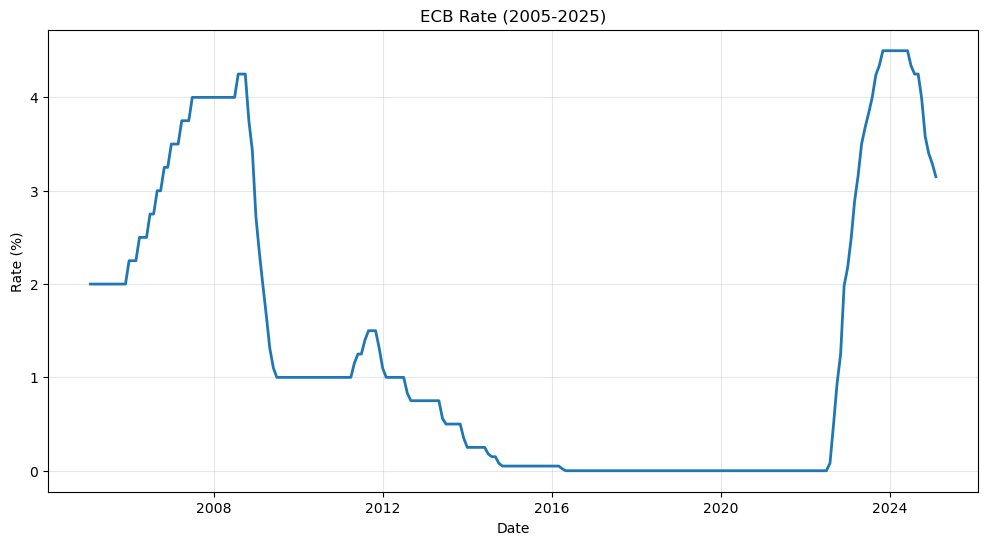

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(df_ecb.index, df_ecb['ecb_rate'], linewidth=2)
plt.title('ECB Rate (2005-2025)')
plt.xlabel('Date')
plt.ylabel('Rate (%)')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Clean All Datasets

Now that we have seen what could be wrong with the data, we can create a general cleaning function in data_loader.py and apply it to all datasets.

In [56]:
from data_loader import clean_dataset, print_data_summary

# Test on ECB
df_ecb_test = clean_dataset(df_ecb_raw, 'ecb_rate')
print(f"Function works: {df_ecb_test.shape == df_ecb.shape}")

Function works: True


### Interest Rates

In [58]:
df_ecb = clean_dataset(df_ecb_raw, 'ecb_rate')
print_data_summary(df_ecb, 'ECB Rate')

df_fed_raw = pd.read_csv(data_raw + 'fed_rate.csv', sep=';')
df_fed = clean_dataset(df_fed_raw, 'FEDFUNDS')
print_data_summary(df_fed, 'Fed Rate')


ECB Rate Summary
Shape: (241, 1)
Date range: 2005-01-31 00:00:00 to 2025-01-31 00:00:00
Missing values: 0

Columns: ['ecb_rate']

First 3 rows:
            ecb_rate
date                
2005-01-31       2.0
2005-02-28       2.0
2005-03-31       2.0

Last 3 rows:
            ecb_rate
date                
2024-11-30      3.40
2024-12-31      3.29
2025-01-31      3.15

Fed Rate Summary
Shape: (243, 1)
Date range: 2004-11-30 00:00:00 to 2025-01-31 00:00:00
Missing values: 0

Columns: ['FEDFUNDS']

First 3 rows:
            FEDFUNDS
date                
2004-11-30      1.93
2004-12-31      2.16
2005-01-31      2.28

Last 3 rows:
            FEDFUNDS
date                
2024-11-30      4.64
2024-12-31      4.48
2025-01-31      4.33


### Equity Returns

In [59]:
# S&P 500 - has percentage format like "+2.5%"
df_spxtr_raw = pd.read_csv(data_raw + 'spxtr.csv', sep=';')
df_spxtr = clean_dataset(df_spxtr_raw, 'spxtr_return', convert_percentage=True)
print_data_summary(df_spxtr, 'S&P 500')

# EuroStoxx 50 - same format
df_stoxx_raw = pd.read_csv(data_raw + 'stoxx50gr_usd.csv', sep=';')
df_stoxx = clean_dataset(df_stoxx_raw, 'stoxx50erusd_return', convert_percentage=True)
print_data_summary(df_stoxx, 'EuroStoxx 50')


S&P 500 Summary
Shape: (240, 1)
Date range: 2005-01-31 00:00:00 to 2024-12-31 00:00:00
Missing values: 0

Columns: ['spxtr_return']

First 3 rows:
            spxtr_return
date                    
2005-01-31     -0.024375
2005-02-28      0.021044
2005-03-31     -0.017708

Last 3 rows:
            spxtr_return
date                    
2024-10-31     -0.009069
2024-11-30      0.058701
2024-12-31     -0.023838

EuroStoxx 50 Summary
Shape: (240, 2)
Date range: 2005-01-31 00:00:00 to 2024-12-31 00:00:00
Missing values: 0

Columns: ['Close', 'stoxx50erusd_return']

First 3 rows:
               Close  stoxx50erusd_return
date                                     
2005-01-31    961.40              -0.0287
2005-02-28  1 004.86               0.0452
2005-03-31    983.06              -0.0217

Last 3 rows:
               Close  stoxx50erusd_return
date                                     
2024-10-31  2 672.77              -0.0595
2024-11-30  2 591.82              -0.0303
2024-12-31  2 590.55       

### FX Data

In [60]:
df_eurusd_raw = pd.read_csv(data_raw + 'eurusd.csv', sep=';')
df_eurusd = clean_dataset(df_eurusd_raw, 'eurusd_midprice', drop_unnamed=False)
print_data_summary(df_eurusd, 'EUR/USD')


EUR/USD Summary
Shape: (241, 1)
Date range: 2004-12-31 00:00:00 to 2024-12-31 00:00:00
Missing values: 0

Columns: ['eurusd_midprice']

First 3 rows:
            eurusd_midprice
date                       
2004-12-31           1.3559
2005-01-31           1.3034
2005-02-28           1.3238

Last 3 rows:
            eurusd_midprice
date                       
2024-10-31           1.0884
2024-11-30           1.0577
2024-12-31           1.0354


### Volatility

In [61]:
df_vix_raw = pd.read_csv(data_raw + 'vix.csv', sep=';')
df_vix = clean_dataset(df_vix_raw, 'vixxmonthly')
print_data_summary(df_vix, 'VIX')

df_vstoxx_raw = pd.read_csv(data_raw + 'vstoxx.csv', sep=';')
df_vstoxx = clean_dataset(df_vstoxx_raw, 'v2txmonthly')
print_data_summary(df_vstoxx, 'VSTOXX')


VIX Summary
Shape: (240, 1)
Date range: 2005-01-31 00:00:00 to 2024-12-31 00:00:00
Missing values: 0

Columns: ['vixxmonthly']

First 3 rows:
            vixxmonthly
date                   
2005-01-31        13.39
2005-02-28        11.68
2005-03-31        13.14

Last 3 rows:
            vixxmonthly
date                   
2024-10-31        19.96
2024-11-30        16.02
2024-12-31        15.69

VSTOXX Summary
Shape: (240, 1)
Date range: 2005-01-31 00:00:00 to 2024-12-31 00:00:00
Missing values: 0

Columns: ['v2txmonthly']

First 3 rows:
            v2txmonthly
date                   
2005-01-31        13.63
2005-02-28        12.64
2005-03-31        12.88

Last 3 rows:
            v2txmonthly
date                   
2024-10-31        19.34
2024-11-30        18.21
2024-12-31        15.89


### Tech Sectors

In [62]:
# Already in decimal format
df_us_tech_raw = pd.read_csv(data_raw + 'us_tech.csv', sep=';')
df_us_tech = clean_dataset(df_us_tech_raw, 'xlk_totalreturn', convert_percentage=False)
print_data_summary(df_us_tech, 'US Tech')

df_eu_tech_raw = pd.read_csv(data_raw + 'eu_tech.csv', sep=';')
df_eu_tech = clean_dataset(df_eu_tech_raw, 'eu_tech_exv3', convert_percentage=False)
print_data_summary(df_eu_tech, 'EU Tech')


US Tech Summary
Shape: (250, 2)
Date range: 2004-12-31 00:00:00 to 2025-09-30 00:00:00
Missing values: 0

Columns: [' (ARCA:XLK) - Dividend Adjusted Share Pricing', 'xlk_totalreturn']

First 3 rows:
             (ARCA:XLK) - Dividend Adjusted Share Pricing  xlk_totalreturn
date                                                                      
2004-12-31                                          15.91        -0.038014
2005-01-31                                          15.31         0.001506
2005-02-28                                          15.33        -0.019549

Last 3 rows:
             (ARCA:XLK) - Dividend Adjusted Share Pricing  xlk_totalreturn
date                                                                      
2025-07-31                                         262.40        -0.001104
2025-08-31                                         262.11         0.075337
2025-09-30                                         281.86         0.066771

EU Tech Summary
Shape: (295, 1)
Dat

## 4. Save Individual Files

In [63]:
df_ecb.to_csv(data_processed + 'ecb_rate_clean.csv')
df_fed.to_csv(data_processed + 'fed_rate_clean.csv')
df_spxtr.to_csv(data_processed + 'spxtr_clean.csv')
df_stoxx.to_csv(data_processed + 'stoxx50gr_usd_clean.csv')
df_eurusd.to_csv(data_processed + 'eurusd_clean.csv')
df_vix.to_csv(data_processed + 'vix_clean.csv')
df_vstoxx.to_csv(data_processed + 'vstoxx_clean.csv')
df_us_tech.to_csv(data_processed + 'us_tech_clean.csv')
df_eu_tech.to_csv(data_processed + 'eu_tech_clean.csv')

print("Saved to 02_data_processed/")

Saved to 02_data_processed/


## 5. Merge Datasets

In [64]:
# Find common date range
datasets = [df_ecb, df_fed, df_spxtr, df_stoxx, df_eurusd, df_vix, df_vstoxx, df_us_tech, df_eu_tech]
common_start = max(df.index.min() for df in datasets)
common_end = min(df.index.max() for df in datasets)

print(f"Common period: {common_start} to {common_end}")

Common period: 2005-01-31 00:00:00 to 2024-12-31 00:00:00


In [65]:
# Align to common dates
df_ecb_aligned = df_ecb.loc[common_start:common_end]
df_fed_aligned = df_fed.loc[common_start:common_end]
df_spxtr_aligned = df_spxtr.loc[common_start:common_end]
df_stoxx_aligned = df_stoxx.loc[common_start:common_end]
df_eurusd_aligned = df_eurusd.loc[common_start:common_end]
df_vix_aligned = df_vix.loc[common_start:common_end]
df_vstoxx_aligned = df_vstoxx.loc[common_start:common_end]
df_us_tech_aligned = df_us_tech.loc[common_start:common_end]
df_eu_tech_aligned = df_eu_tech.loc[common_start:common_end]

print(f"All datasets now have {len(df_ecb_aligned)} rows")

All datasets now have 240 rows


In [66]:
# Create final dataset
df_final = pd.DataFrame(index=df_ecb_aligned.index)
df_final['ecb_rate'] = df_ecb_aligned['ecb_rate']
df_final['fed_rate'] = df_fed_aligned['FEDFUNDS']
df_final['spxtr_return'] = df_spxtr_aligned['spxtr_return']
df_final['stoxx50gr_return'] = df_stoxx_aligned['stoxx50erusd_return']
df_final['eurusd'] = df_eurusd_aligned['eurusd_midprice']
df_final['vix'] = df_vix_aligned['vixxmonthly']
df_final['vstoxx'] = df_vstoxx_aligned['v2txmonthly']
df_final['us_tech_return'] = df_us_tech_aligned['xlk_totalreturn']
df_final['eu_tech_return'] = df_eu_tech_aligned['eu_tech_exv3']

print(f"Final dataset: {df_final.shape}")
print(f"Missing values: {df_final.isnull().sum().sum()}")
print("\nFirst rows:")
print(df_final.head())

Final dataset: (240, 9)
Missing values: 0

First rows:
            ecb_rate  fed_rate  spxtr_return  stoxx50gr_return  eurusd    vix  vstoxx  \
date                                                                                    
2005-01-31       2.0      2.28     -0.024375           -0.0287  1.3034  13.39   13.63   
2005-02-28       2.0      2.50      0.021044            0.0452  1.3238  11.68   12.64   
2005-03-31       2.0      2.63     -0.017708           -0.0217  1.2963  13.14   12.88   
2005-04-30       2.0      2.79     -0.018966           -0.0387  1.2873  14.46   14.48   
2005-05-31       2.0      3.00      0.031819            0.0147  1.2310  13.95   14.33   

            us_tech_return eu_tech_return  
date                                       
2005-01-31        0.001506          -0.02  
2005-02-28       -0.019549           0.03  
2005-03-31       -0.035276          -0.02  
2005-04-30        0.069422          -0.02  
2005-05-31       -0.012884           0.10  


In [67]:
df_final.to_csv(data_processed + 'final_merged_data.csv')
print("Saved: final_merged_data.csv")

Saved: final_merged_data.csv


## Summary

- Cleaned 9 datasets
- Aligned to common date range
- Created final merged dataset
- Ready for feature engineering